In [29]:
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from textwrap import wrap
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
#INICIALIZARON
RANDOM_SEED = 42
MAX_LEN = 150
BATCH_SIZE = 10
NCLASSES = 3

In [3]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [5]:
df = pd.read_csv("data.csv")
print(f'Columnas: {df.columns}')
print(df)
df= df.rename(columns={'Texto': 'Text'})

Columnas: Index(['Id', 'Texto', 'Label', 'Lenguaje'], dtype='object')
        Id                                           Texto  Label Lenguaje
0        1   "Bájale de huevos o te parto tu madre idiota"  toxic  español
1        2                    "Beaners are parasitic scum"   hate   ingles
2        3  "Eres un desperdicio de espacio pinche baboso"  toxic  español
3        4               "All shemales belong in the oven"   hate   ingles
4        5               "Fome venecos weones comen gatos"   hate  español
...    ...                                             ...    ...      ...
5088  5089                            "GG well played bro"  clean   ingles
5089  5090                              "Gender is binary"   hate   ingles
5090  5091                 "Me cagan los nacos asquerosos"   hate  español
5091  5092               "deja de repetir lo mismo idiota"  toxic  español
5092  5093                    "Que te folle un pez pelele"  toxic  español

[5093 rows x 4 columns]


In [6]:
#REAJUSTE DE DATA
df['Label'] = df['Label'].map({
    'clean' : 0,
    'toxic' : 1,
    'hate' : 2
 })
df.head()

,Id,Text,Label,Lenguaje
0,1,"""Bájale de huevos o te parto tu madre idiota""",1,español
1,2,"""Beaners are parasitic scum""",2,ingles
2,3,"""Eres un desperdicio de espacio pinche baboso""",1,español
3,4,"""All shemales belong in the oven""",2,ingles
4,5,"""Fome venecos weones comen gatos""",2,español


In [7]:
#TOKENIZACION
PRE_TRAINED_MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
#EJEMPLO TOKENIZACION
simple_tex = "bro eres un pendejo 😴"
tokens = tokenizer.tokenize(simple_tex)
tokens_ids = tokenizer.convert_tokens_to_ids(tokens)
print('frase', simple_tex)
print('tokens', tokens)
print('tokens numericos', tokens_ids)

frase bro eres un pendejo 😴
tokens ['bro', 'ere', '##s', 'un', 'pen', '##dej', '##o', '[UNK]']
tokens numericos [93742, 14378, 10107, 10119, 66558, 90062, 10133, 100]


In [9]:
#CODIFICACION PARA INTRUDUCIR BERTH
encoding = tokenizer(
    simple_tex,
    max_length = 15,
    truncation = True,
    add_special_tokens = True,
    return_token_type_ids = False,
    padding = 'max_length',
    return_attention_mask = True,
    return_tensors = 'pt'
)

In [10]:
encoding.keys()

KeysView({'input_ids': tensor([[  101, 93742, 14378, 10107, 10119, 66558, 90062, 10133,   100,   102,
             0,     0,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]])})

In [11]:
print(tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]))
print(encoding['input_ids'][0])
print(encoding['attention_mask'][0])

['[CLS]', 'bro', 'ere', '##s', 'un', 'pen', '##dej', '##o', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
tensor([  101, 93742, 14378, 10107, 10119, 66558, 90062, 10133,   100,   102,
            0,     0,     0,     0,     0])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0])


In [12]:
class IMBDataset(Dataset):
    def __init__(self, Text, Label, tokenizer, max_len):
        self.Text = Text
        self.Label = Label
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.Text)

    def __getitem__(self, item):
        text = str(self.Text[item])
        label = self.Label[item]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            add_special_tokens=True,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'Text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [13]:
#DATA LOADER
def data_loader(df, tokenizer, max_len, batch_size):
    dataset = IMBDataset(
        Text=df.Text.to_numpy(),
        Label=df.Label.to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0
    )

In [14]:
#seperacion de data para las pruebas
df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=df['Label']
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=df_temp['Label']
)

train_data_loader = data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader   = data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader  = data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [15]:
print("\n=== DIAGNÓSTICO DE DATOS ===")
print(f"Total de registros: {len(df)}")
print(f"\nDistribución de clases:")
print(df['Label'].value_counts())

# Probar un batch
sample_batch = next(iter(train_data_loader))
print(f"\nForma de input_ids: {sample_batch['input_ids'].shape}")
print(f"Forma de attention_mask: {sample_batch['attention_mask'].shape}")
print(f"Forma de labels: {sample_batch['labels'].shape}")
print(f"Labels en el batch: {sample_batch['labels']}")
print(f"Ejemplo de texto: {sample_batch['Text'][0]}")


=== DIAGNÓSTICO DE DATOS ===
Total de registros: 5093

Distribución de clases:
Label
0    2000
1    1650
2    1443
Name: count, dtype: int64

Forma de input_ids: torch.Size([10, 150])
Forma de attention_mask: torch.Size([10, 150])
Forma de labels: torch.Size([10])
Labels en el batch: tensor([0, 1, 1, 0, 0, 1, 0, 0, 0, 1])
Ejemplo de texto: "I like the clarity of this."


In [16]:
class BERTModerador(nn.Module):

  def __init__(self,n_classes):
    super(BERTModerador,self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.dropout = nn.Dropout(p=0.3)
    self.linear = nn.Linear(
        self.bert.config.hidden_size,
        n_classes
    )

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(
        input_ids = input_ids,
        attention_mask = attention_mask
    )
    pooled_output = outputs.pooler_output
    x = self.dropout(pooled_output)
    logits = self.linear(x)
    return logits


In [17]:
model = BERTModerador(NCLASSES)
model = model.to(device)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
print(model)

BERTModerador(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [19]:
#ENTRENAMIENTO
EPOCHS = 10

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

# Optimizador
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)


total_steps = len(train_data_loader) * EPOCHS

# Scheduler (control del learning rate)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Función de pérdida
loss_fn = nn.CrossEntropyLoss().to(device)

In [24]:
#ENTRENAMIENTO BASE
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()
  losses = []
  correct_predictions = 0
  for batch in data_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    outputs = model(input_ids, attention_mask)
    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, labels)
    correct_predictions += torch.sum(preds == labels)
    losses.append(loss.item())
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()
  return correct_predictions.double()/n_examples, np.mean(losses)



In [25]:
#EVALUAR MODELO
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)

            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            #guardar F1
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = correct_predictions.double() / n_examples
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, np.mean(losses), f1, all_labels, all_preds #agregamos all_labels, all_preds que son necesario para el classification_report


In [26]:
#ENTRENAMIENTO!!
for epoch in range(EPOCHS):
    print('Epoch {} de {}'.format(epoch + 1, EPOCHS))
    print('--------------------')

    train_acc, train_loss = train_model(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(df_train)
    )

    test_acc, test_loss, test_f1, _, _  = eval_model(
    model,
    test_data_loader,
    loss_fn,
    device,
    len(df_test)
    )

    print('Entrenamiento: Loss: {}, accuracy: {}'.format(train_loss, train_acc))
    print(
        'Validación: Loss: {}, accuracy: {}, F1: {}'.format(
            test_loss, test_acc, test_f1
        )
    )
    print()

Epoch 1 de 10
--------------------
Entrenamiento: Loss: 0.03270057937649962, accuracy: 0.9949509116409537
Validación: Loss: 0.1954356255939581, accuracy: 0.9672774869109948, F1: 0.9673234300299942

Epoch 2 de 10
--------------------
Entrenamiento: Loss: 0.028297732560129064, accuracy: 0.9943899018232819
Validación: Loss: 0.18243880059389403, accuracy: 0.9764397905759163, F1: 0.9763049483608954

Epoch 3 de 10
--------------------
Entrenamiento: Loss: 0.013026627927703238, accuracy: 0.9983169705469846
Validación: Loss: 0.17294495323264303, accuracy: 0.9751308900523561, F1: 0.9750750990426106

Epoch 4 de 10
--------------------
Entrenamiento: Loss: 0.011781666134957763, accuracy: 0.9974754558204769
Validación: Loss: 0.17577997486754518, accuracy: 0.9764397905759163, F1: 0.9762950948167601

Epoch 5 de 10
--------------------
Entrenamiento: Loss: 0.0014128759297110526, accuracy: 0.9997194950911641
Validación: Loss: 0.1856310285492528, accuracy: 0.9777486910994765, F1: 0.9777472925798284

Ep

In [28]:
#agregamos classification_report
_, _, _, all_labels, all_preds = eval_model(
    model,
    test_data_loader, #usamos el test
    loss_fn,
    device,
    len(df_test)
)

print(classification_report(
    all_labels,
    all_preds,
    target_names=["clean", "toxic", "hate"]
    ))

              precision    recall  f1-score   support

       clean       0.97      0.98      0.98       300
       toxic       0.98      0.97      0.97       248
        hate       0.98      0.97      0.98       216

    accuracy                           0.98       764
   macro avg       0.98      0.98      0.98       764
weighted avg       0.98      0.98      0.98       764



In [30]:
# Calcular la matriz de confusion con las predicciones que ya se obtuvieron
cm = confusion_matrix(all_labels, all_preds)
print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[295   3   2]
 [  5 241   2]
 [  3   3 210]]


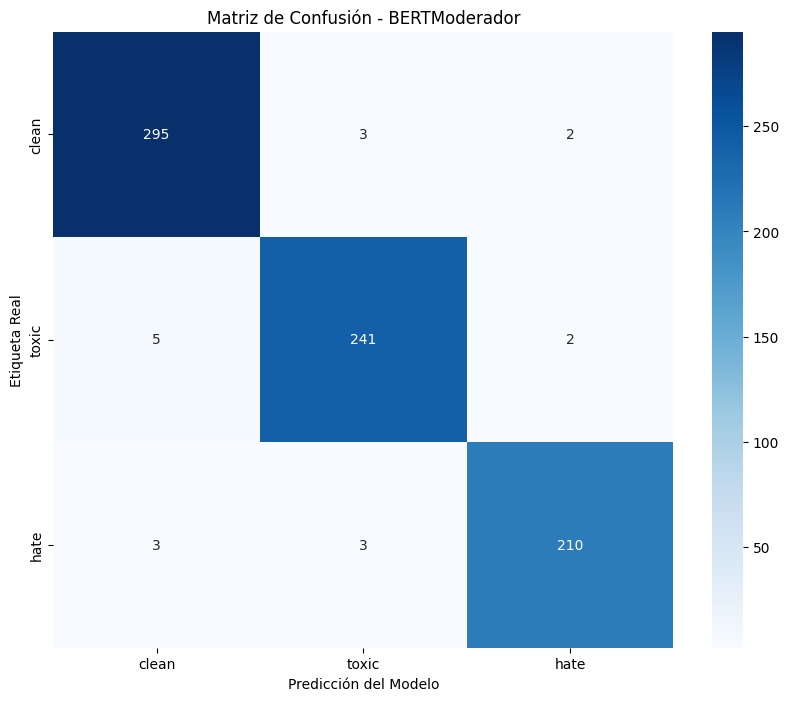

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'toxic', 'hate'],
            yticklabels=['clean', 'toxic', 'hate'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión - BERTModerador')
plt.show()

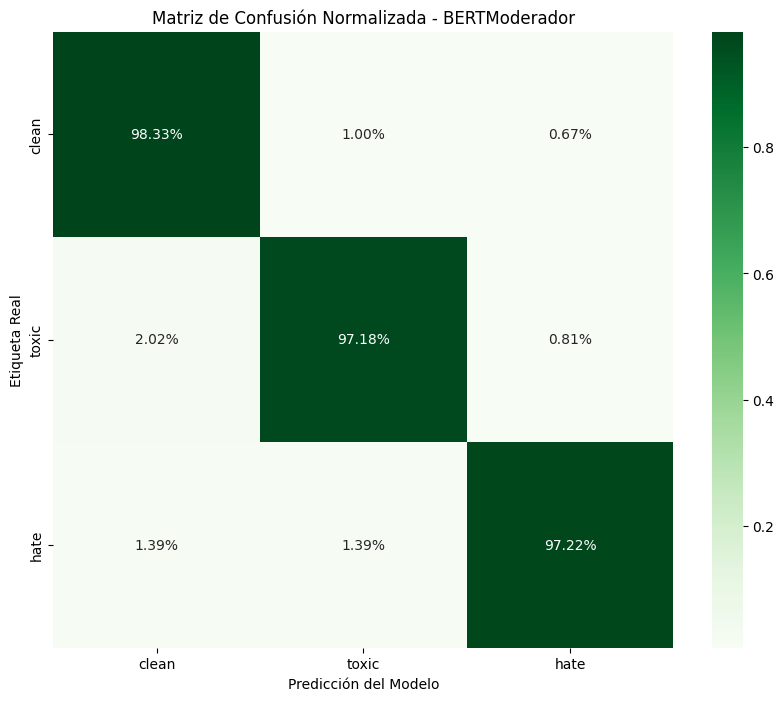

In [32]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['clean', 'toxic', 'hate'],
            yticklabels=['clean', 'toxic', 'hate'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión Normalizada - BERTModerador')
plt.show()